<a href="https://colab.research.google.com/github/donjadao/lis4693/blob/main/Lab-4/Dao_Don_Lab4Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment 4: Supervised Machine Learning [DUE Mar 12]

Installing and loading libraries

In [1]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


My assigned data is not a csv, but rather multiple text files, I chose the top 50 for both positive and negative training data since the files altogher are too large for github.

In [2]:
import requests

base_api = "https://api.github.com/repos/donjadao/lis4693/contents/Lab-4/IMBD_data"

A function to load all the reviews from the folder

In [3]:
def load_reviews(label):
    url = f"{base_api}/{label}"
    response = requests.get(url)
    response.raise_for_status()
    files = response.json()

    texts = []
    labels = []

    for file in files:
        raw_url = file["download_url"]
        text = requests.get(raw_url).text
        texts.append(text)
        labels.append(label)

    return texts, labels

Loading the individual text files in each folder

In [4]:
pos_texts, pos_labels = load_reviews("train pos")
neg_texts, neg_labels = load_reviews("train neg")

texts = pos_texts + neg_texts
labels = pos_labels + neg_labels

print("Loaded", len(texts), "reviews")

Loaded 100 reviews


Since I don't have a csv to work with, i will create a dataframe with just the text and the labels as the columns

In [5]:
import pandas as pd

df = pd.DataFrame({
    "review": texts,
    "label": labels
})

df.head()

,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,train pos
1,"I'm a male, not given to women's movies, but t...",train pos
2,Liked Stanley & Iris very much. Acting was ver...,train pos
3,Liked Stanley & Iris very much. Acting was ver...,train pos
4,"The production quality, cast, premise, authent...",train pos


It looks like we will be doing text analysis primarily with the review of each movie. Seeing what kind of sentiment people might have, emotions, thoughts, the vocabulary and see if they differ beteen positive and negative reviews.

In [11]:
# Features and target (following professor's naming)
features = df['review']
target = df['label']

Convert labels to 1's and 0's

In [14]:
# Features and target (following professor's naming)
features = df['review']
target = df['label']

# Clean labels BEFORE mapping
target = target.astype(str).str.strip().str.lower()

# Remove the "train " prefix
target = target.str.replace("train ", "", regex=False)

print("Cleaned labels:", target.unique())

# Map to numeric like professor did
target_names = {
    'pos': '1',
    'neg': '0'
}

target = target.map(target_names)

# Drop NaN rows
df_clean = pd.DataFrame({
    "review": features,
    "label": target
}).dropna()

features = df_clean["review"]
target = df_clean["label"]

print("Final labels:", target.unique())
print("Total rows:", len(df_clean))

Cleaned labels: ['pos' 'neg']
Final labels: ['1' '0']
Total rows: 100


# Task 2:
SPlit and preprocess

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# 70:30 split (assignment requirement)
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.30, random_state=42
)

print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Replace NaN with empty strings (professor's exact step)
X_train = X_train.fillna('')
X_test = X_test.fillna('')

# Professor's preprocessing pipeline
preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

y_test.unique()

Training set has 70 samples.
Testing set has 30 samples.
Preprocessing training data...
Preprocessing test data...


array(['0', '1'], dtype=object)

Finding Classifiers

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr", max_iter=1000)
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...
Training Adaboost classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Random Forest classifier...


RandomForestClassifier()

Generate predictions

In [18]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

compute accuracy

In [19]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.6
SVM Accuracy: 0.8333333333333334
LR Accuracy: 0.6666666666666666
ADA Accuracy: 0.5666666666666667
RF Accuracy: 0.5666666666666667


Classification reporting, first defining again what is 0 and 1

In [20]:
target_names_list = ['0', '1']   # 0 = neg, 1 = pos

In [21]:
from sklearn.metrics import classification_report

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_predictions, target_names=target_names_list))

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_predictions, target_names=target_names_list))

print("=== AdaBoost ===")
print(classification_report(y_test, ada_predictions, target_names=target_names_list))

print("=== Random Forest ===")
print(classification_report(y_test, random_predictions, target_names=target_names_list))

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.52      1.00      0.68        13
           1       1.00      0.29      0.45        17

    accuracy                           0.60        30
   macro avg       0.76      0.65      0.57        30
weighted avg       0.79      0.60      0.55        30

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.57      1.00      0.72        13
           1       1.00      0.41      0.58        17

    accuracy                           0.67        30
   macro avg       0.78      0.71      0.65        30
weighted avg       0.81      0.67      0.64        30

=== AdaBoost ===
              precision    recall  f1-score   support

           0       0.50      0.54      0.52        13
           1       0.62      0.59      0.61        17

    accuracy                           0.57        30
   macro avg       0.56      0.56      0.56        30
weighted 

In [23]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Parameter grid for SVM
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [24]:
print("Best SVM Parameters")
print(svm_best.best_params_)

best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Parameters
{'C': 1000}
Best SVM Accuracy: 0.8


In [25]:
from sklearn.metrics import classification_report

print("=== SVM Classification Report ===")
print(classification_report(y_test, svm_predictions, target_names=['0', '1']))

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        13
           1       1.00      0.71      0.83        17

    accuracy                           0.83        30
   macro avg       0.86      0.85      0.83        30
weighted avg       0.88      0.83      0.83        30



Based on all the evaluation metrics across precision, recall, accuracy, and F1-score, the Support Vector Machine (SVM) classifier performed the best on this dataset. It achieved the highest accuracy and showed a balanced performance across both classes. Therefor it is the strongest.

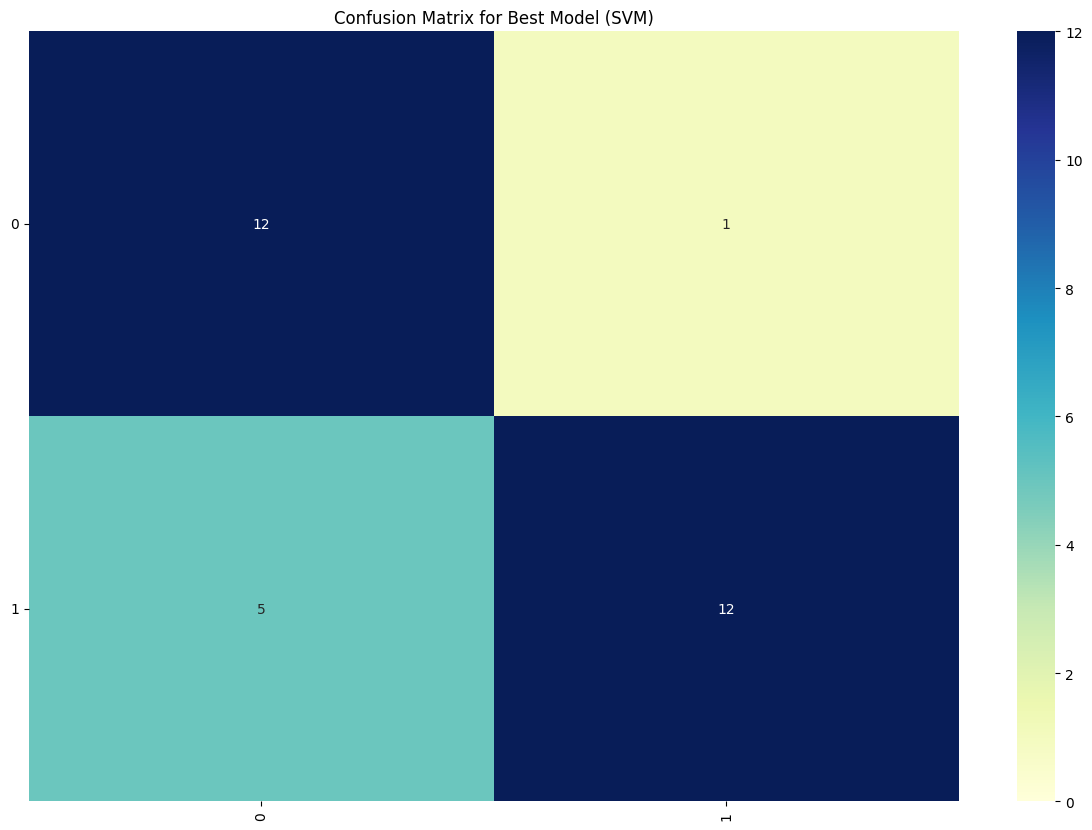

In [27]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix for the best model (SVM)
conf_matrix = confusion_matrix(y_test, best_svm_predictions)

# Use string labels '0' and '1' for rows/columns
conf_matrix_df = pd.DataFrame(conf_matrix, index=['0', '1'], columns=['0', '1'])

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title("Confusion Matrix for Best Model (SVM)")
plt.show()

Now, we will use the machine learning model that selected with AdaBoost Classifier to run on the data it has never seen to make predictions aka Supervised Machine Learning!

For this task, we will now upload new dataset with empty "code_choice" column.

In [31]:
import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/donjadao/lis4693/main/Lab-4/new-data.csv"
response = requests.get(url)
response.raise_for_status()
raw_csv_data = response.text

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

  This movie was surprisingly heartfelt and emotional.,
0       Terrible pacing and weak acting throughout.,   
1    I loved the cinematography and the soundtrack.,   
2  Not my type of film, but I can see why others ...   
3  The plot twist at the end completely shocked me.,   
4       Predictable storyline with flat characters.,   


I could not get the text to function but i realised i did not have a label for the columns

In [38]:
new_data.columns

Index(['This movie was surprisingly heartfelt and emotional.,'], dtype='object')

I forgot to add the code_choice column so i will do that here in colab

In [39]:
# Rename the single column to AB
new_data.columns = ['AB']

# Add the empty code_choice column
new_data['code_choice'] = ""

In [40]:
text = new_data['AB']

In [41]:
text

,AB
0,"Terrible pacing and weak acting throughout.,"
1,"I loved the cinematography and the soundtrack.,"
2,"Not my type of film, but I can see why others ..."
3,"The plot twist at the end completely shocked me.,"
4,"Predictable storyline with flat characters.,"
...,...
96,"A visually bland and uninspired film.,"
97,"The story was simple but effective.,"
98,"The story was overly complicated for no reason.,"
99,"A delightful surprise that I thoroughly enjoyed.,"


In [44]:
new_text_preprocessed = preprocessing.transform(text.fillna(''))

In [45]:
best_svm_predictions = svm_best.predict(new_text_preprocessed)

In [48]:
df2 = pd.DataFrame(best_svm_predictions)
df2.rename(columns={0: 'code_choice'}, inplace=True)

In [49]:
new_data['code_choice'] = df2['code_choice']

In [50]:
combined_df = new_data
display(combined_df.head())

,AB,code_choice
0,"Terrible pacing and weak acting throughout.,",1
1,"I loved the cinematography and the soundtrack.,",1
2,"Not my type of film, but I can see why others ...",0
3,"The plot twist at the end completely shocked me.,",1
4,"Predictable storyline with flat characters.,",1


In [52]:
combined_df.to_csv('predicted_data.csv', index=False)

I reviewed the first 20 reviews and the model got ALL of the positive reviews correctly identified. However, It did mis label many negative reviews as positive. Out of the 20 it labelled 5 negative reviews as positive.

# Reflection

Overall, the process went well and the model was able to predict/label the categoreis pretty well in the new dataset. However, it did fail to catch some negative reviews. My idea is that it isn't able to identify anything emotions reviewers might say, but that also isn't consistent. The model probably needs more input and text to learn from since I only gave it 50 negative and 50 positive reviews. Any new language that it tries to predict might result in a misclassification.
Also for the process, It was difficult getting started since my original data was not already in csv but sepereate text files. 100 total seperate files.